# Data Dimensionality Reduction

Manufacturing big data is often multidimensional and complex, presenting a significant challenge during the analysis process. Because these datasets contain a vast number of variables, they can lead to the Curse of Dimensionality.

#### 1. The Curse of Dimensionality
As the number of dimensions (features) increases, the distance between data points becomes diluted. This makes it difficult for models to learn patterns effectively, ultimately leading to a decline in performance.

In the manufacturing industry, where hundreds of sensors collect various types of data in real-time, processing and analyzing this information efficiently is essential.

One of the key methods to solve this is **Dimensionality Reduction**. By using these techniques, we can preserve the most important information in the data while removing unnecessary noise or redundant features. Transforming the data into a lower-dimensional space reduces computational costs and improves overall model performance.

#### 2. Principal Component Analysis (PCA)

- **Principal Component Analysis (PCA)** is one of the most representative dimensionality reduction techniques. 
- It is highly effective in manufacturing for analyzing multidimensional data by identifying the directions (principal components) along which the variation in the data is maximal.

#### 3. Advantages of PCA
- **Reduction in Computational Cost**: By reducing high-dimensional data into a lower-dimensional space, you can significantly decrease the time and resources required for computation. Since manufacturing data is often vast, dimensionality reduction enables much more efficient analysis.

- **Data Visualization**: Compressing high-dimensional data into 2D or 3D makes it much easier to visually interpret the distribution. For example, by reducing a dataset with more than 10 variables down to 2 dimensions and plotting it, you can easily identify clustering patterns or data distributions that indicate specific machine states.

- **Improved Model Performance**: By removing redundant or unnecessary variables, PCA helps prevent overfitting and enhances the model's ability to generalize to new data. It is particularly effective at preventing overfitting when a model is burdened with too many input features.

#### Scenario 1: 
- Dimensionality reduction of multi-sensor data to maintain core information while simplifying the dataset.
  - In this scenario, we will take a high-dimensional dataset (multiple sensors) and use PCA to compress the information into a smaller number of variables.

In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic manufacturing big data
np.random.seed(42)
data = {
    'Sensor_ID': np.arange(1, 21),
    'Temperature': np.random.normal(75, 10, 20),
    'Pressure': np.random.normal(1000, 50, 20),
    'Humidity': np.random.uniform(30, 70, 20),
    'Vibration': np.random.uniform(0.1, 1.0, 20),
    'Production_Time': np.random.normal(30, 5, 20),
    'Energy_Consumption': np.random.normal(100, 20, 20)
}

# Create DataFrame
df = pd.DataFrame(data)

# Display DataFrame (Before dimensionality reduction)
print("Data before dimensionality reduction:")
print(df)


# ---------- Data Dimensionality Reduction ---------- #

# 1. Remove unnecessary columns 
# (Sensor_ID is an identifier, not a feature, so it's excluded from PCA)
df_features = df.drop('Sensor_ID', axis=1)

# 2. Data Scaling: Standardize the data before applying PCA
# PCA is sensitive to variances of the initial variables.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

# 3. Apply PCA: Reduce 6-dimensional data down to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# Convert PCA results into a new DataFrame
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])

# Calculate the explained variance ratio
# This tells us how much information (variance) is captured by each principal component.
explained_variance = pca.explained_variance_ratio_

# Display dimensionality reduction results
print("\n Data after dimensionality reduction (PCA results):")
print(df_pca)

print("\n PCA Explained Variance Ratio:")
print(explained_variance)
print(f"Total information retained: {np.sum(explained_variance):.2%}")

# ---------- End of Data Dimensionality Reduction ---------- #

Data before dimensionality reduction:
    Sensor_ID  Temperature     Pressure   Humidity  Vibration  \
0           1    79.967142  1073.282438  68.783385   0.795020   
1           2    73.617357   988.711185  61.005313   0.278844   
2           3    81.476885  1003.376410  67.579958   0.104970   
3           4    90.230299   928.762591  65.793094   0.833915   
4           5    72.658466   972.780864  53.915999   0.736172   
5           6    72.658630  1005.546129  66.874969   0.756106   
6           7    90.792128   942.450321  33.539700   0.794143   
7           8    82.674347  1018.784901  37.839314   0.166640   
8           9    70.305256   969.968066  31.809092   0.422619   
9          10    80.425600   985.415313  43.013213   0.204282   
10         11    70.365823   969.914669  45.547092   0.876793   
11         12    70.342702  1092.613909  40.853961   0.660968   
12         13    77.419623   999.325139  63.149500   0.397808   
13         14    55.867198   947.114454  44.270133  

In [21]:
loadings = pd.DataFrame(pca.components_, columns=df_features.columns, index=['PC1','PC2'])
print(loadings)

     Temperature  Pressure  Humidity  Vibration  Production_Time  \
PC1     0.150821 -0.560210 -0.046122   0.491458         0.067075   
PC2     0.180846 -0.039871 -0.591733   0.129045        -0.761394   

     Energy_Consumption  
PC1            0.644407  
PC2           -0.138506  


#### Result Analysis
The results of the Principal Component Analysis (PCA) provide a quantitative look at how the manufacturing sensor data has been compressed.

**1. Analysis of Information Retention (Variance)**
- Individual Variance: PC1 captures 26.6% of the data's patterns, and PC2 captures 22.2%.
- Total Retained Information: 48.80%.

> Interpretation: This means that by reducing 6 variables into 2, we have retained about half of the original information. In a real-world manufacturing setting, a 48.8% retention rate suggests that the sensors are quite independent and do not share a single strong trend. To capture more detail (e.g., 80% or more), we might need to increase the number of components to 3 or 4.

**2. Analysis of Principal Component Loadings (Feature Influence)**
- The "loadings" tell us which original sensors contribute most to each new component.
- PC1 (The "Energy & Vibration" Axis)
  - Strongest Factor: Energy_Consumption (0.64) and Vibration (0.49).
  - Inverse Factor: Pressure (-0.56).
> PC1 represents a state where high energy use and high vibration occur together, often while pressure is low. This could be an indicator of a specific machine mode or a heavy-load cycle.

- PC2 (The "Efficiency & Humidity" Axis)
  - Strongest Factor: Production_Time (-0.76) and Humidity (-0.59).
> PC2 is heavily influenced by production speed and humidity. Since both are strongly negative, a low PC2 score actually indicates high production time and high humidity.

#### Scenario 2:
- Optimizing Data Processing and Visualization by Reducing High-Dimensional Sensor Features
  - In this scenario, we focus on Efficiency and Interpretability. In a smart factory, managing hundreds of sensors simultaneously can lead to system lag and "information overload" for operators. By using PCA, we simplify the data structure, which speeds up real-time processing and allows for a 2D/3D visual dashboard.

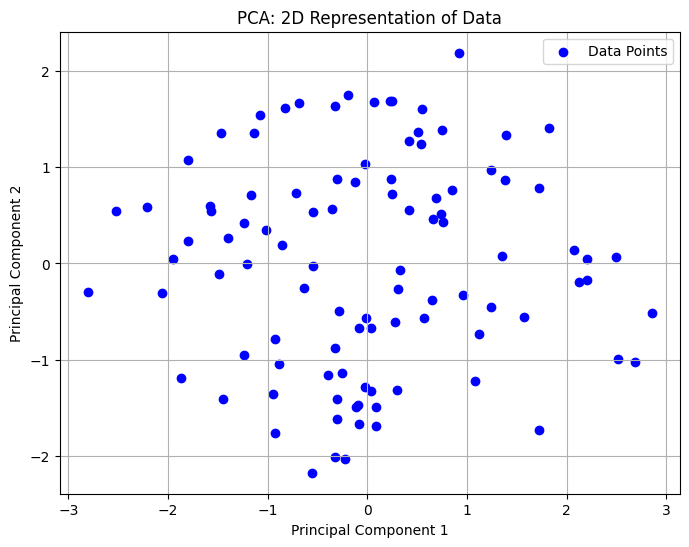

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generate synthetic data (e.g., 100 samples and 5 features)
np.random.seed(42)
data = np.random.rand(100, 5)

# Standardize the data
# PCA is sensitive to variances, so scaling to mean=0 and variance=1 is essential.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Perform dimensionality reduction using the PCA model
pca = PCA(n_components=2) # Reduce to 2 dimensions
data_pca = pca.fit_transform(data_scaled)

# Convert PCA results into a DataFrame
df_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

# Visualize the dimensionally reduced data
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c='blue', label='Data Points')
plt.title('PCA: 2D Representation of Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()